In [1]:
import os
print(os.getcwd())

import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

/content


In [2]:
iris_df = sns.load_dataset('iris')
iris_df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris_df.isnull().any()

,0
sepal_length,False
sepal_width,False
petal_length,False
petal_width,False
species,False


In [4]:
iris_df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


In [5]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


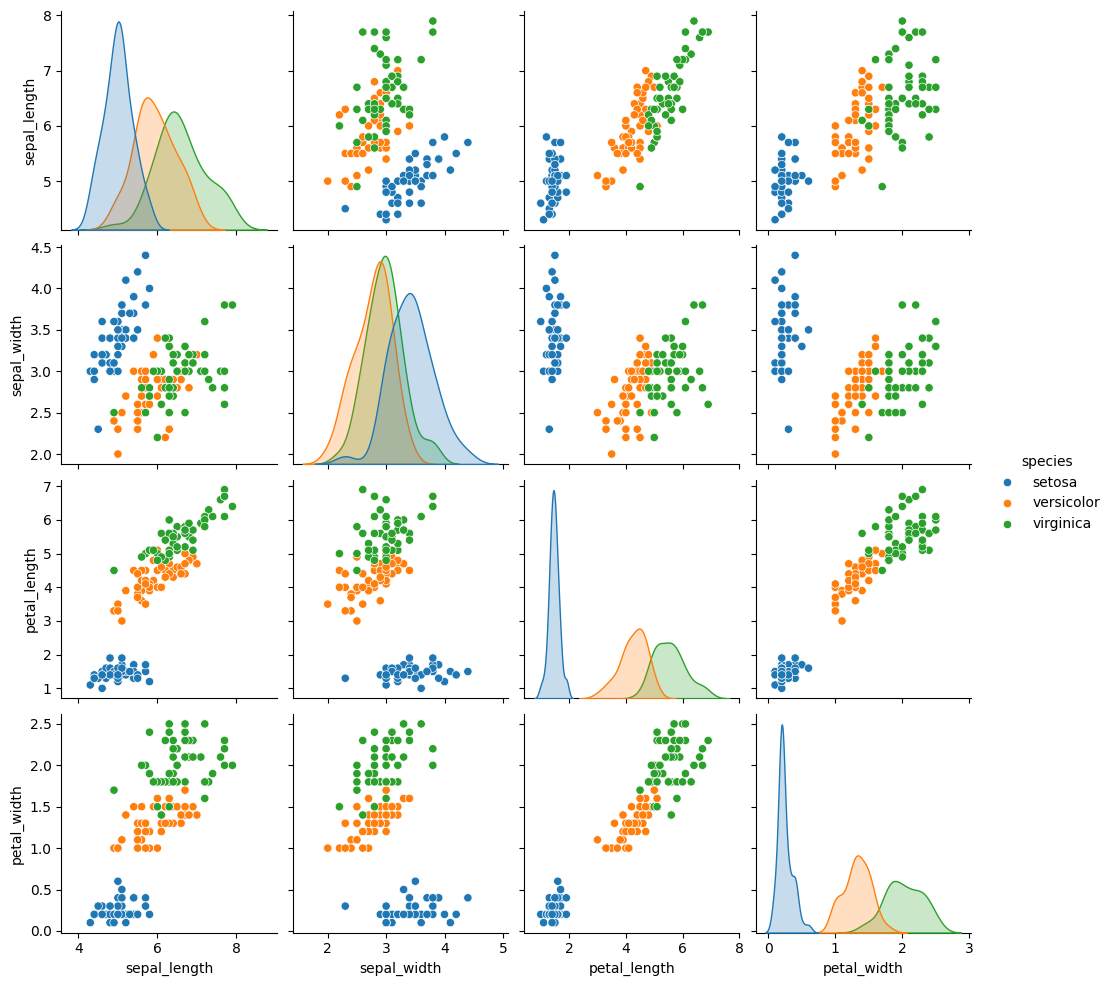

In [6]:
sns.pairplot(iris_df, hue='species')

plt.savefig("exercise2a.png")
plt.show()

In [7]:
X = iris_df[
    ['sepal_length',
     'sepal_width',
     'petal_length',
     'petal_width']
].values

y = iris_df['species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.9,
    random_state=1
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (135, 4)
Testing data: (15, 4)


In [8]:
clf = tree.DecisionTreeClassifier()

clf = clf.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [9]:
prediction = clf.predict(X_test)

print(prediction)

['setosa' 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor'
 'virginica' 'setosa' 'setosa' 'virginica' 'versicolor' 'setosa'
 'virginica' 'versicolor' 'versicolor']


In [10]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         6
   virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



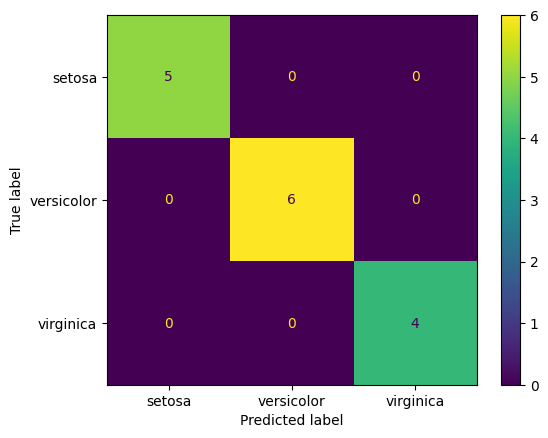

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test
)

plt.savefig("exercise2b.png")
plt.show()

In [12]:
!pip install pydotplus
!apt-get -qq install graphviz

In [13]:
from io import StringIO
from IPython.display import Image, display
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import pydotplus

In [14]:
iris = load_iris()

X = iris.data
y = iris.target

clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

clf.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=42)

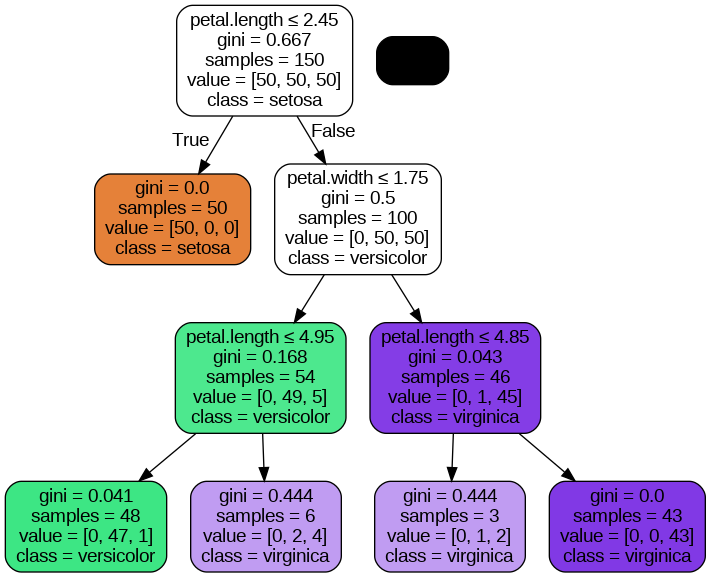

In [15]:
dot_data = StringIO()

export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=[
        'sepal.length',
        'sepal.width',
        'petal.length',
        'petal.width'
    ],
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(
    dot_data.getvalue()
)

graph.write_png("exercise2c.png")

display(Image(graph.create_png()))

In [16]:
Sepal Length = 4.8
Sepal Width  = 2.9
Petal Length = 1.3
Petal Width  = 0.2

SyntaxError: invalid syntax (2401282792.py, line 1)

In [17]:
SepalLengthCm = 4.8
SepalWidthCm = 2.9
PetalLengthCm = 1.3
PetalWidthCm = 0.2

x = [[
    SepalLengthCm,
    SepalWidthCm,
    PetalLengthCm,
    PetalWidthCm
]]

res = clf.predict(x)

class_mapping = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}

predicted_class = class_mapping[res[0]]

print("The class predicted is --> " + predicted_class)

The class predicted is --> setosa
